# GDP Modeling with Trade Data (Log + Robust Errors)

In [31]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.api import het_breuschpagan
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR



# Load data
df = pd.read_csv('casestudy2.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Log transformation
df_log = df.copy() + 1e-6
df_log = np.log(df_log)

X_log = df_log.drop(columns=['GDP'])
y_log = df_log['GDP']


In [32]:

def reduce_multicollinearity(data, threshold=10.0):
    data = sm.add_constant(data)
    variables = data.columns.tolist()
    while True:
        vif = [variance_inflation_factor(data[variables].values, i) for i in range(len(variables))]
        max_vif = max(vif)
        if max_vif > threshold:
            max_vif_index = vif.index(max_vif)
            if variables[max_vif_index] == 'const':
                break
            del variables[max_vif_index]
        else:
            break
    return data[variables]

X_log_reduced = reduce_multicollinearity(X_log)


In [ ]:

# Fit OLS model with robust standard errors (HC3)
robust_se_model = sm.OLS(y_log, X_log_reduced).fit(cov_type='HC3')
print(robust_se_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     825.6
Date:                Tue, 17 Jun 2025   Prob (F-statistic):          2.31e-171
Time:                        16:57:19   Log-Likelihood:                 598.12
No. Observations:                 279   AIC:                            -1182.
Df Residuals:                     272   BIC:                            -1157.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [ ]:

# Normality test
residuals = robust_se_model.resid
fitted_vals = robust_se_model.fittedvalues
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: W={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# Homoscedasticity test
bp_test = het_breuschpagan(residuals, X_log_reduced)
labels = ['Lagrange Multiplier statistic', 'p-value', 'f-value', 'f p-value']
print("\nBreusch-Pagan Test Results:")
for name, value in zip(labels, bp_test):
    print(f"{name}: {value:.4f}")


Shapiro-Wilk Test: W=0.9955, p-value=0.5910

Breusch-Pagan Test Results:
Lagrange Multiplier statistic: 22.1841
p-value: 0.0011
f-value: 3.9160
f p-value: 0.0009


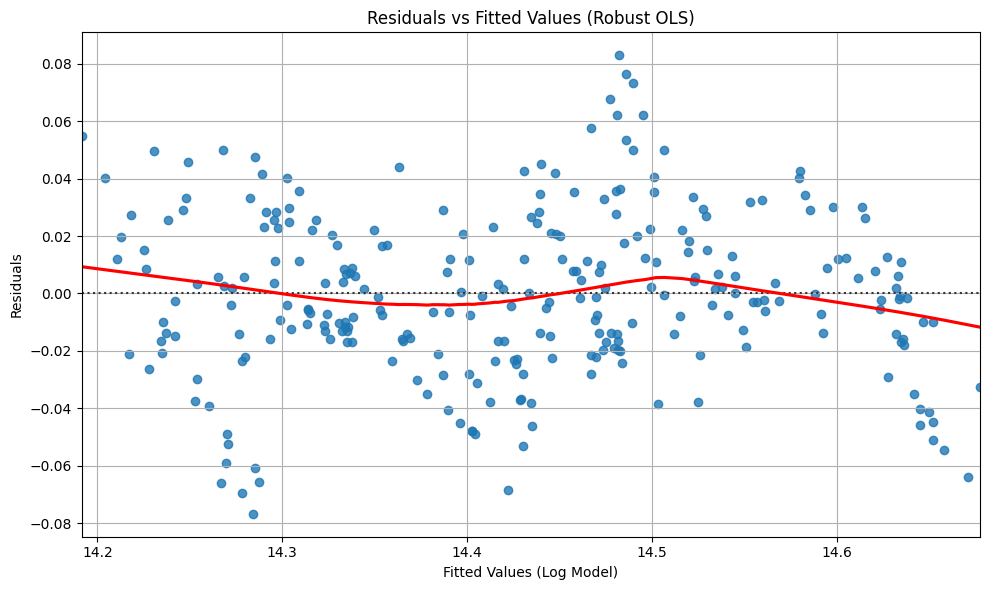

In [ ]:

plt.figure(figsize=(10, 6))
sns.residplot(x=fitted_vals, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Fitted Values (Log Model)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Robust OLS)")
plt.grid(True)
plt.tight_layout()
plt.show()


## 🔮 Advanced Forecasting Models: ARIMAX and VAR

In [ ]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# First differences to ensure stationarity
df_diff = df_log.diff().dropna()

# Augmented Dickey-Fuller test for stationarity
adf_results = {col: adfuller(df_diff[col])[1] for col in df_diff.columns}
for col, pval in adf_results.items():
    print(f"ADF p-value for {col}: {pval:.4f}")


ADF p-value for GDP: 0.0000
ADF p-value for Exports_Manufacturing: 0.0000
ADF p-value for Exports_Total_of_all_industries: 0.0000
ADF p-value for Exports_Wholesale_trade: 0.0000
ADF p-value for Imports_Manufacturing: 0.0001
ADF p-value for Imports_Total_of_all_industries: 0.0000
ADF p-value for Imports_Wholesale_trade: 0.0000


In [ ]:

# Fit ARIMAX model with GDP as dependent variable and trade data as exogenous variables
exog_vars = df_diff.drop(columns=['GDP'])
arimax_model = SARIMAX(df_diff['GDP'], exog=exog_vars, order=(1, 0, 1)).fit(disp=False)

print(arimax_model.summary())


                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                  278
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 936.591
Date:                Tue, 17 Jun 2025   AIC                          -1855.182
Time:                        16:57:20   BIC                          -1822.533
Sample:                    02-01-2002   HQIC                         -1842.084
                         - 03-01-2025                                         
Covariance Type:                  opg                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Exports_Manufacturing               0.0113      0.030      0.375      0.707      -0.048       0.070
Exports_Total_of_all_industries     0.0208      0.029      0.723    

In [ ]:

# Fit VAR model using all variables as endogenous
var_model = VAR(df_diff)
var_results = var_model.fit(maxlags=4, ic='aic')

print(var_results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 17, Jun, 2025
Time:                     16:57:20
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                   -45.4847
Nobs:                     274.000    HQIC:                  -47.0872
Log likelihood:           4079.62    FPE:                1.21926e-21
AIC:                     -48.1616    Det(Omega_mle):     6.02909e-22
--------------------------------------------------------------------
Results for equation GDP
                                        coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------------------
const                                      0.001631         0.000550            2.966           0.003
L1.GDP                                     0.550496         0.066315            

📊 Granger Causality Tests: Do trade variables help predict GDP?



,p-values,min p-value,Significant (<0.05)
Exports_Manufacturing,"[0.0011, 0.0019, 0.0036, 0.0039]",0.0011,True
Exports_Total_of_all_industries,"[0.0019, 0.001, 0.0014, 0.0014]",0.001,True
Exports_Wholesale_trade,"[0.0024, 0.0, 0.0, 0.0]",0.0,True
Imports_Manufacturing,"[0.0, 0.0009, 0.0028, 0.0016]",0.0,True
Imports_Total_of_all_industries,"[0.0002, 0.004, 0.0104, 0.0043]",0.0002,True
Imports_Wholesale_trade,"[0.07, 0.0609, 0.1069, 0.0897]",0.0609,False



📈 Impulse Response Functions: Shock to trade variables → GDP



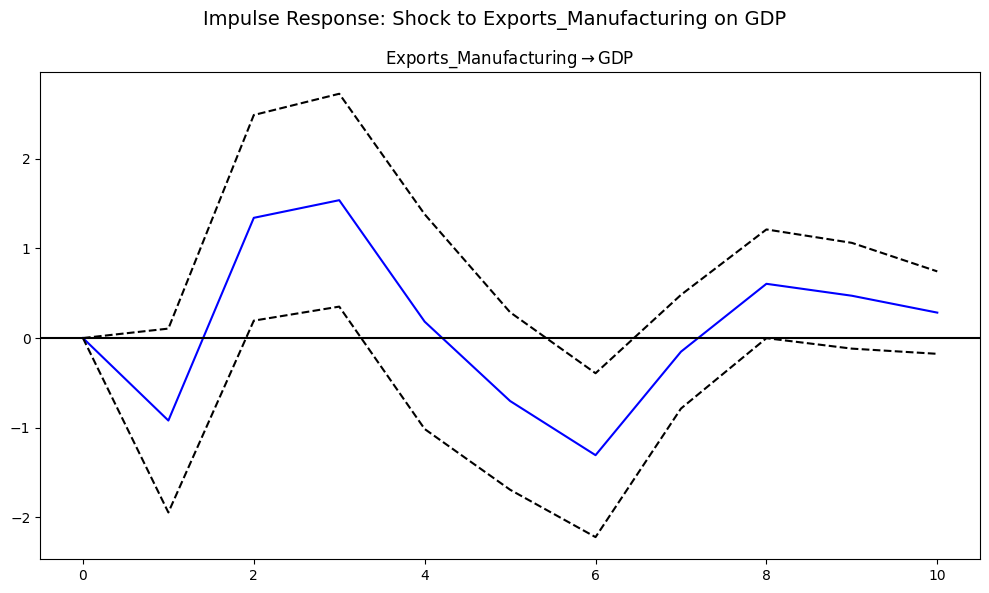

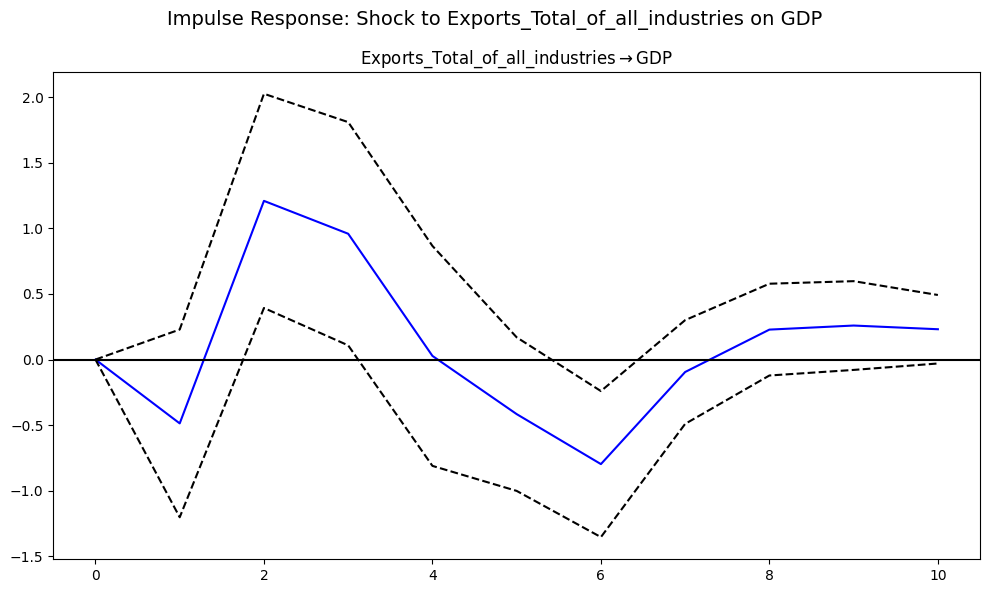

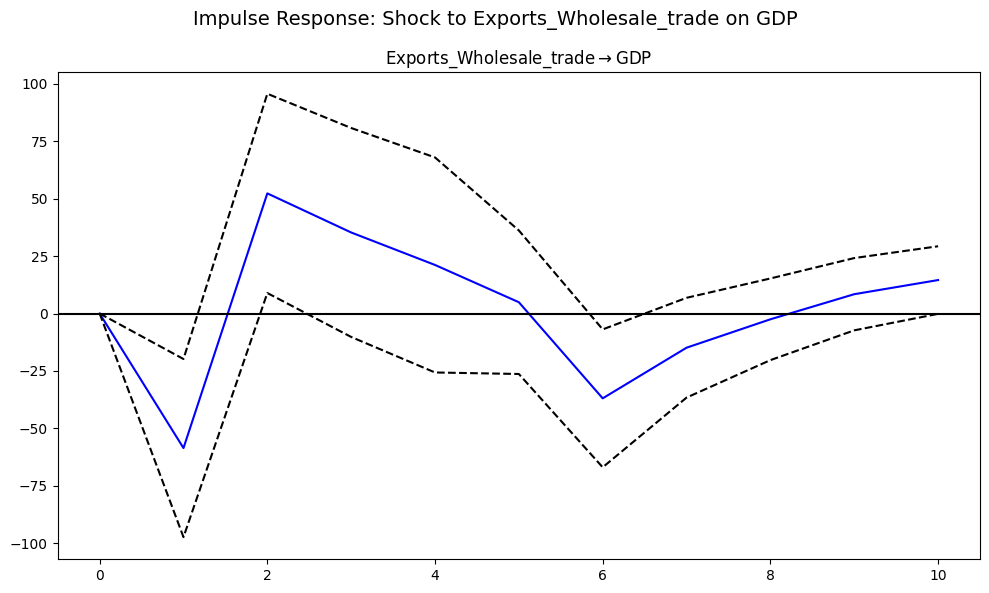

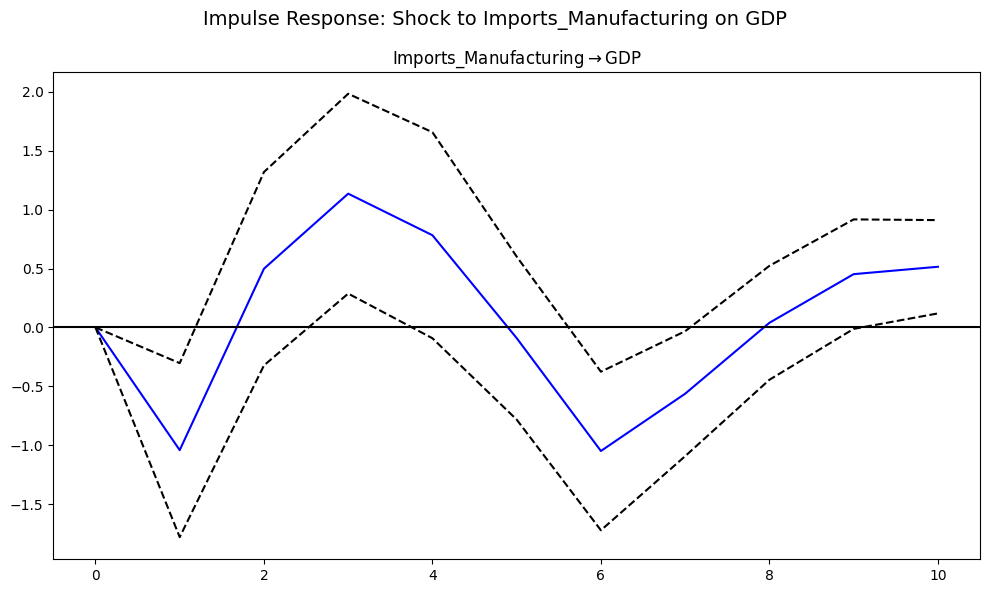

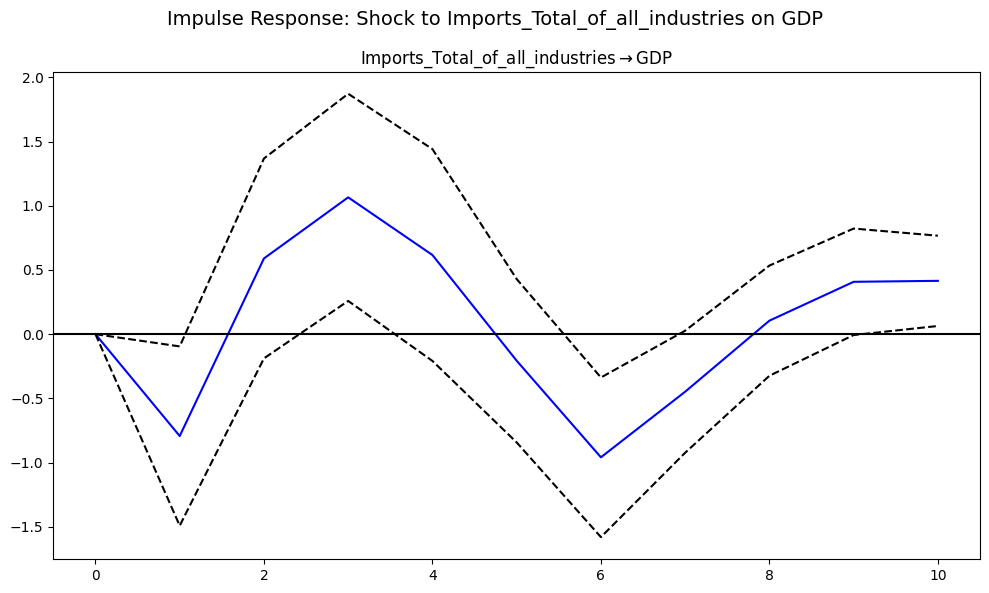

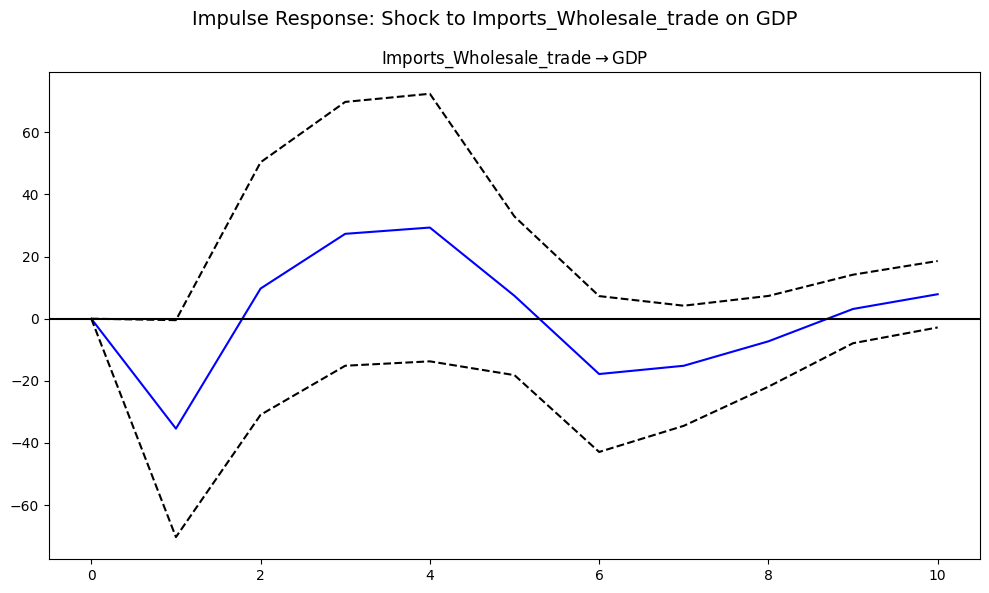

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Load dataset
df = pd.read_csv("casestudy2.csv")  # Replace with your actual path if needed

# Define GDP and trade-related variables
target = 'GDP'
trade_vars = [
    'Exports_Manufacturing',
    'Exports_Total_of_all_industries',
    'Exports_Wholesale_trade',
    'Imports_Manufacturing',
    'Imports_Total_of_all_industries',
    'Imports_Wholesale_trade'
]

# Prepare differenced data (to ensure stationarity)
df_diff = df[[target] + trade_vars].diff().dropna()

# --- Granger Causality Tests ---
print("📊 Granger Causality Tests: Do trade variables help predict GDP?\n")
results = {}

for var in trade_vars:
    test_result = grangercausalitytests(df_diff[[target, var]], maxlag=4, verbose=False)
    pvals = [round(test_result[i + 1][0]['ssr_ftest'][1], 4) for i in range(4)]
    min_pval = min(pvals)
    results[var] = {"p-values": pvals, "min p-value": min_pval}

results_df = pd.DataFrame(results).T
results_df["Significant (<0.05)"] = results_df["min p-value"] < 0.05
display(results_df)

# --- Impulse Response Functions (IRFs) ---
print("\n📈 Impulse Response Functions: Shock to trade variables → GDP\n")

for var in trade_vars:
    model_data = df_diff[[target, var]]
    model = VAR(model_data)
    results = model.fit(maxlags=4, ic='aic')
    irf = results.irf(10)
    
    fig = irf.plot(impulse=var, response=target, orth=False, figsize=(10, 6))
    fig.suptitle(f'Impulse Response: Shock to {var} on GDP', fontsize=14)
    plt.tight_layout()
    plt.show()
